In [42]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# NSE Stocks to Analyze
tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS"
]

def fetch_stock_data(ticker, period="6mo", interval="1d"):
    """
    Downloads historical stock data from Yahoo Finance.
    """

    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    # Flatten MultiIndex columns if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["Ticker"] = ticker
    df.reset_index(inplace=True)

    return df


# Download data for all selected stocks
all_data = []

for ticker in tickers:
    print(f"Downloading {ticker}...")
    all_data.append(fetch_stock_data(ticker))

raw_data = (
    pd.concat(all_data)
    .reset_index(drop=True)
)

print(f"\nTotal Records: {len(raw_data)}")
display(raw_data.head())


Total Records: 372


Price,Date,Close,High,Low,Open,Volume,Ticker
0,2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495,RELIANCE.NS
1,2025-12-29,1538.486694,1550.929166,1536.495899,1547.743942,5972105,RELIANCE.NS
2,2025-12-30,1532.713379,1546.449794,1530.722584,1539.880194,8815884,RELIANCE.NS
3,2025-12-31,1563.172607,1569.742208,1533.907890,1533.907890,5771830,RELIANCE.NS
4,2026-01-01,1568.348511,1585.170755,1563.869221,1566.457231,6408128,RELIANCE.NS


In [3]:
def engineer_features(df):
    """
    Creates trading behaviour features for anomaly detection.
    """

    df = df.copy()

    # Rolling averages
    df["Volume_MA20"] = df["Volume"].rolling(20).mean()
    df["MA20"] = df["Close"].rolling(20).mean()

    # Feature 1: Unusual trading volume
    df["Volume_Spike"] = (
        df["Volume"] /
        df["Volume_MA20"]
    )

    # Feature 2: Daily price movement (%)
    df["Price_Change_Pct"] = (
        df["Close"]
        .pct_change() * 100
    )

    # Feature 3: Intraday volatility
    df["Day_Range_Pct"] = (
        (df["High"] - df["Low"])
        / df["Low"] * 100
    )

    # Feature 4: Distance from moving average
    df["Price_Deviation"] = (
        (df["Close"] - df["MA20"])
        / df["MA20"] * 100
    )

    # Feature 5: Combined price-volume pressure
    df["Volume_Price_Pressure"] = (
        df["Volume_Spike"]
        * abs(df["Price_Change_Pct"])
    )

    df.dropna(inplace=True)

    return df


# Apply feature engineering to each stock
featured_data = []

for ticker in tickers:

    ticker_df = raw_data[
        raw_data["Ticker"] == ticker
    ].copy()

    ticker_df = engineer_features(
        ticker_df
    )

    featured_data.append(
        ticker_df
    )

final_df = (
    pd.concat(featured_data)
    .reset_index(drop=True)
)

print(f"Feature Engineered Dataset: {final_df.shape}")

display(
    final_df[
        [
            "Ticker",
            "Volume_Spike",
            "Price_Change_Pct",
            "Day_Range_Pct",
            "Price_Deviation",
            "Volume_Price_Pressure"
        ]
    ].head(10)
)

Feature Engineered Dataset: (315, 14)


Price,Ticker,Volume_Spike,Price_Change_Pct,Day_Range_Pct,Price_Deviation,Volume_Price_Pressure
0,RELIANCE.NS,1.412639,-0.149509,1.756272,-6.014090,0.211202
1,RELIANCE.NS,0.855043,-1.169345,1.882694,-6.571224,0.999840
2,RELIANCE.NS,2.100471,-0.404011,1.725144,-6.428033,0.848613
3,RELIANCE.NS,0.880057,1.173482,1.805184,-4.868619,1.032731
4,RELIANCE.NS,1.556748,-0.408100,1.365609,-4.674448,0.635310
5,RELIANCE.NS,0.824473,0.316320,1.414581,-3.778790,0.260797
6,RELIANCE.NS,1.115200,-0.358316,4.298018,-3.451481,0.399594
7,RELIANCE.NS,1.705519,3.358739,4.146277,0.282262,5.728393
8,RELIANCE.NS,0.596453,1.370828,1.645487,1.837459,0.817634
9,RELIANCE.NS,0.840274,-0.919828,1.528308,1.115611,0.772907


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Features used for anomaly detection
feature_cols = [
    "Volume_Spike",
    "Price_Change_Pct",
    "Day_Range_Pct",
    "Price_Deviation",
    "Volume_Price_Pressure"
]

# Remove zero-volume days
final_df = final_df[
    final_df["Volume"] > 0
].reset_index(drop=True)

result_frames = []

# Train one model per stock
for ticker in tickers:

    stock_df = final_df[
        final_df["Ticker"] == ticker
    ].copy()

    scaler = StandardScaler()

    X = scaler.fit_transform(
        stock_df[feature_cols]
    )

    model = IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42
    )

    model.fit(X)

    stock_df["Anomaly_Score"] = (
        model.decision_function(X)
    )

    stock_df["Is_Anomaly"] = (
        model.predict(X)
    )

    result_frames.append(stock_df)

# Combine results
final_df = (
    pd.concat(result_frames)
    .reset_index(drop=True)
)

final_df["Is_Anomaly"] = (
    final_df["Is_Anomaly"]
    .map({1: "Normal", -1: "ANOMALY"})
)

print(final_df["Is_Anomaly"].value_counts())

Is_Anomaly
Normal     291
ANOMALY     18
Name: count, dtype: int64


In [5]:
# Reset column names if required
if isinstance(final_df.columns, pd.MultiIndex):
    final_df.columns = final_df.columns.get_level_values(0)

# Extract detected anomalies
anomalies = (
    final_df[
        final_df["Is_Anomaly"] == "ANOMALY"
    ][
        [
            "Ticker",
            "Date",
            "Volume_Spike",
            "Price_Change_Pct",
            "Volume_Price_Pressure",
            "Anomaly_Score",
            "Is_Anomaly"
        ]
    ]
    .sort_values("Anomaly_Score")
)

print(f"Total Anomalies Found: {len(anomalies)}")

display(anomalies)

Total Anomalies Found: 18


Price,Ticker,Date,Volume_Spike,Price_Change_Pct,Volume_Price_Pressure,Anomaly_Score,Is_Anomaly
189,TCS.NS,2026-06-03,2.768624,-8.386120,23.218009,-0.137688,ANOMALY
188,TCS.NS,2026-06-02,2.247453,6.507356,14.624976,-0.119448,ANOMALY
214,INFY.NS,2026-02-04,3.500771,-7.258455,25.410190,-0.081789,ANOMALY
111,TCS.NS,2026-02-04,3.173249,-7.013296,22.254935,-0.075382,ANOMALY
28,RELIANCE.NS,2026-03-05,2.083272,3.301117,6.877125,-0.062267,ANOMALY
291,INFY.NS,2026-06-02,2.267972,5.679839,12.881717,-0.054308,ANOMALY
221,INFY.NS,2026-02-13,3.691528,-1.219342,4.501234,-0.049851,ANOMALY
47,RELIANCE.NS,2026-04-06,1.433551,-3.391338,4.861657,-0.049515,ANOMALY
117,TCS.NS,2026-02-12,2.755954,-5.488354,15.125654,-0.034710,ANOMALY
266,INFY.NS,2026-04-24,2.846846,-6.932133,19.734717,-0.023934,ANOMALY


In [48]:
from sklearn.preprocessing import MinMaxScaler

# Convert anomaly score into an intuitive 0–100 risk score
risk_scaler = MinMaxScaler()

final_df["Risk_Score"] = (
    risk_scaler.fit_transform(
        (-final_df["Anomaly_Score"]).values.reshape(-1, 1)
    ) * 100
)

final_df["Risk_Score"] = final_df["Risk_Score"].round(1)

display(
    final_df[
        [
            "Ticker",
            "Anomaly_Score",
            "Risk_Score"
        ]
    ].head()
)

        Ticker  Anomaly_Score  Risk_Score
0  RELIANCE.NS       0.097284        37.9
1  RELIANCE.NS       0.171416        19.5
2  RELIANCE.NS       0.151200        24.6
3  RELIANCE.NS       0.088080        40.2
4  RELIANCE.NS       0.182685        16.8


In [7]:
from sklearn.preprocessing import MinMaxScaler

risk_scaler = MinMaxScaler()

final_df["Risk_Score"] = (
    risk_scaler.fit_transform(
        (-final_df["Anomaly_Score"]).values.reshape(-1, 1)
    ) * 100
)

final_df["Risk_Score"] = final_df["Risk_Score"].round(1)

In [8]:
# Explain WHY each anomaly was flagged
def explain_anomaly(row):

    reasons = []

    if row['Volume_Spike'] > 2:
        reasons.append(
            f"Trading volume was {row['Volume_Spike']:.1f}x higher than the 20-day average"
        )

    if abs(row['Price_Change_Pct']) > 5:
        reasons.append(
            f"Price moved sharply by {abs(row['Price_Change_Pct']):.1f}% in a single session"
        )

    if row['Volume_Price_Pressure'] > 10:
        reasons.append(
            f"Strong volume-price pressure detected ({row['Volume_Price_Pressure']:.1f})"
        )

    if row['Day_Range_Pct'] > 4:
        reasons.append(
            f"Intraday volatility reached {row['Day_Range_Pct']:.1f}%"
        )

    if abs(row['Price_Deviation']) > 8:
        reasons.append(
            f"Price deviated {abs(row['Price_Deviation']):.1f}% from its 20-day moving average"
        )

    if not reasons:
        reasons.append(
            "Multiple moderate indicators collectively triggered anomaly detection"
        )

    return " | ".join(reasons)

# Apply explanation only to anomalies
anomalies = final_df[final_df['Is_Anomaly'] == 'ANOMALY'].copy()
anomalies['Why_Flagged'] = anomalies.apply(explain_anomaly, axis=1)

# Final anomaly report
report = anomalies[
    [
        "Ticker",
        "Date",
        "Risk_Score",
        "Anomaly_Score",
        "Why_Flagged"
    ]
].copy()
report['Anomaly_Score'] = report['Anomaly_Score'].round(4)
report = report.sort_values('Anomaly_Score')  # most suspicious first

print(f"Total Anomalies: {len(report)}")

display(report)

Total Anomalies: 18


Price,Ticker,Date,Risk_Score,Anomaly_Score,Why_Flagged
189,TCS.NS,2026-06-03,100.0,-0.1377,Trading volume was 2.8x higher than the 20-day...
188,TCS.NS,2026-06-02,95.4,-0.1194,Trading volume was 2.2x higher than the 20-day...
214,INFY.NS,2026-02-04,85.8,-0.0818,Trading volume was 3.5x higher than the 20-day...
111,TCS.NS,2026-02-04,84.2,-0.0754,Trading volume was 3.2x higher than the 20-day...
28,RELIANCE.NS,2026-03-05,80.9,-0.0623,Trading volume was 2.1x higher than the 20-day...
291,INFY.NS,2026-06-02,78.9,-0.0543,Trading volume was 2.3x higher than the 20-day...
221,INFY.NS,2026-02-13,77.7,-0.0499,Trading volume was 3.7x higher than the 20-day...
47,RELIANCE.NS,2026-04-06,77.6,-0.0495,Intraday volatility reached 5.3%
117,TCS.NS,2026-02-12,73.9,-0.0347,Trading volume was 2.8x higher than the 20-day...
266,INFY.NS,2026-04-24,71.2,-0.0239,Trading volume was 2.8x higher than the 20-day...


In [9]:
# Top 10 highest-risk trading events
top_risks = (
    final_df
    .sort_values(
        "Risk_Score",
        ascending=False
    )[
        [
            "Ticker",
            "Date",
            "Risk_Score",
            "Anomaly_Score",
            "Is_Anomaly"
        ]
    ]
    .head(10)
)

print("Top 10 Highest Risk Trading Events")

display(top_risks)

Top 10 Highest Risk Trading Events


Price,Ticker,Date,Risk_Score,Anomaly_Score,Is_Anomaly
189,TCS.NS,2026-06-03,100.0,-0.137688,ANOMALY
188,TCS.NS,2026-06-02,95.4,-0.119448,ANOMALY
214,INFY.NS,2026-02-04,85.8,-0.081789,ANOMALY
111,TCS.NS,2026-02-04,84.2,-0.075382,ANOMALY
28,RELIANCE.NS,2026-03-05,80.9,-0.062267,ANOMALY
291,INFY.NS,2026-06-02,78.9,-0.054308,ANOMALY
221,INFY.NS,2026-02-13,77.7,-0.049851,ANOMALY
47,RELIANCE.NS,2026-04-06,77.6,-0.049515,ANOMALY
117,TCS.NS,2026-02-12,73.9,-0.034710,ANOMALY
266,INFY.NS,2026-04-24,71.2,-0.023934,ANOMALY


In [10]:
# Categorize each anomaly into a business-friendly risk level
def risk_level(score):

    if score >= 80:
        return "Critical"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"


final_df["Risk_Level"] = final_df["Risk_Score"].apply(risk_level)

print("Risk Level Distribution")

display(
    final_df[
        [
            "Ticker",
            "Risk_Score",
            "Risk_Level"
        ]
    ].head()
)

print("Risk Level Distribution")
display(
    final_df["Risk_Level"]
    .value_counts()
)

Risk Level Distribution


Price,Ticker,Risk_Score,Risk_Level
0,RELIANCE.NS,22.9,Low
1,RELIANCE.NS,29.4,Low
2,RELIANCE.NS,45.2,Medium
3,RELIANCE.NS,23.0,Low
4,RELIANCE.NS,22.3,Low


Risk_Level
Low         263
Medium       25
High         16
Critical      5
Name: count, dtype: int64

In [12]:
stock_ranking = (
    final_df[
        final_df["Is_Anomaly"] == "ANOMALY"
    ]
    .groupby("Ticker")
    .agg(
        Total_Anomalies=("Ticker", "count"),
        Avg_Risk_Score=("Risk_Score", "mean"),
        Max_Risk_Score=("Risk_Score", "max")
    )
    .reset_index()
    .sort_values(
        "Avg_Risk_Score",
        ascending=False
    )
)

print("Stock Risk Ranking")

display(stock_ranking)

Stock Risk Ranking


,Ticker,Total_Anomalies,Avg_Risk_Score,Max_Risk_Score
2,TCS.NS,6,81.133333,100.0
0,INFY.NS,6,74.166667,85.8
1,RELIANCE.NS,6,71.400000,80.9


In [13]:
# Executive Summary

total_days = len(final_df)

total_anomalies = len(
    final_df[
        final_df["Is_Anomaly"] == "ANOMALY"
    ]
)

anomaly_rate = (
    total_anomalies / total_days
) * 100

highest_risk_stock = (
    stock_ranking.iloc[0]["Ticker"]
)

avg_risk_score = (
    final_df[
        final_df["Is_Anomaly"] == "ANOMALY"
    ]["Risk_Score"]
    .mean()
)

print("=" * 50)
print("EXECUTIVE SUMMARY")
print("=" * 50)

print(f"Trading Days Analysed : {total_days}")
print(f"Anomalies Detected    : {total_anomalies}")
print(f"Anomaly Rate (%)      : {anomaly_rate:.2f}%")
print(f"Highest Risk Stock    : {highest_risk_stock}")
print(f"Average Risk Score    : {avg_risk_score:.2f}")

EXECUTIVE SUMMARY
Trading Days Analysed : 309
Anomalies Detected    : 18
Anomaly Rate (%)      : 5.83%
Highest Risk Stock    : TCS.NS
Average Risk Score    : 75.57


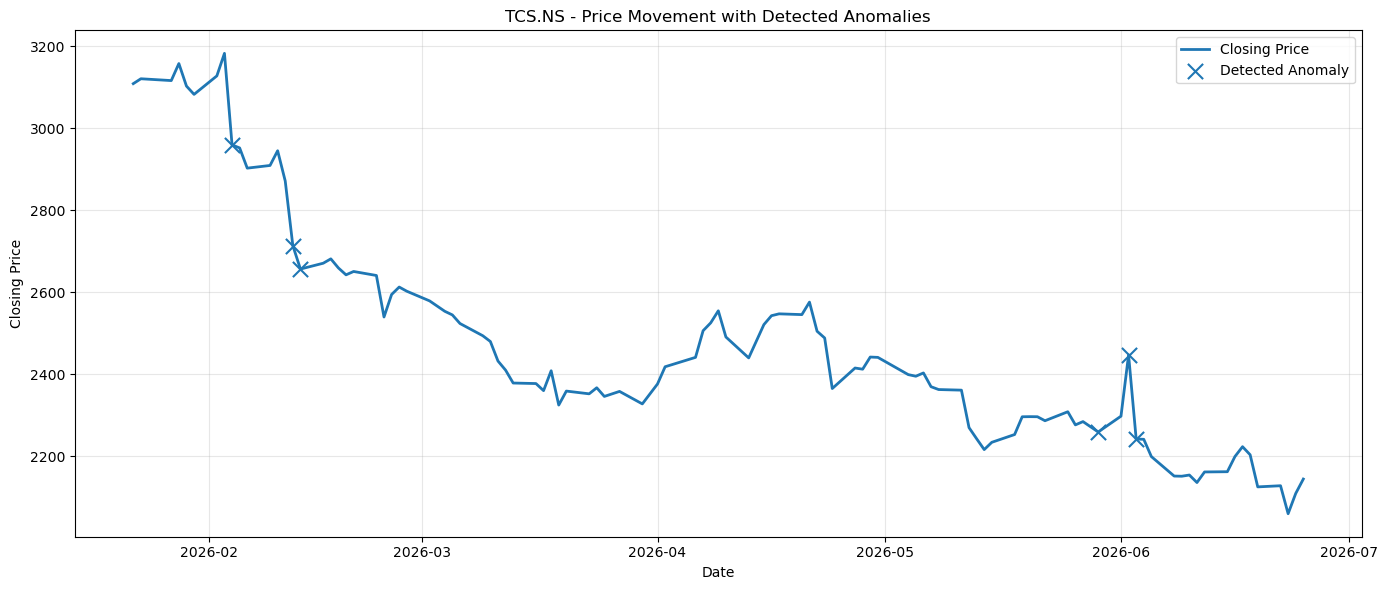

In [14]:
import matplotlib.pyplot as plt

# Select stock to visualize
ticker = "TCS.NS"

stock_data = final_df[
    final_df["Ticker"] == ticker
]

anomaly_data = stock_data[
    stock_data["Is_Anomaly"] == "ANOMALY"
]

plt.figure(figsize=(14, 6))

plt.plot(
    stock_data["Date"],
    stock_data["Close"],
    linewidth=2,
    label="Closing Price"
)

plt.scatter(
    anomaly_data["Date"],
    anomaly_data["Close"],
    marker="x",
    s=120,
    label="Detected Anomaly"
)

plt.title(f"{ticker} - Price Movement with Detected Anomalies")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()